100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.4MB/s]


Autoencoder_fashionMNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=784, bias=True)
    (9): Sigmoid()
  )
)
Training of the model starts...
Epoch 1| Train Loss 0.053154
Epoch 2| Train Loss 0.042032
Epoch 3| Train Loss 0.036531
Epoch 4| Train Los

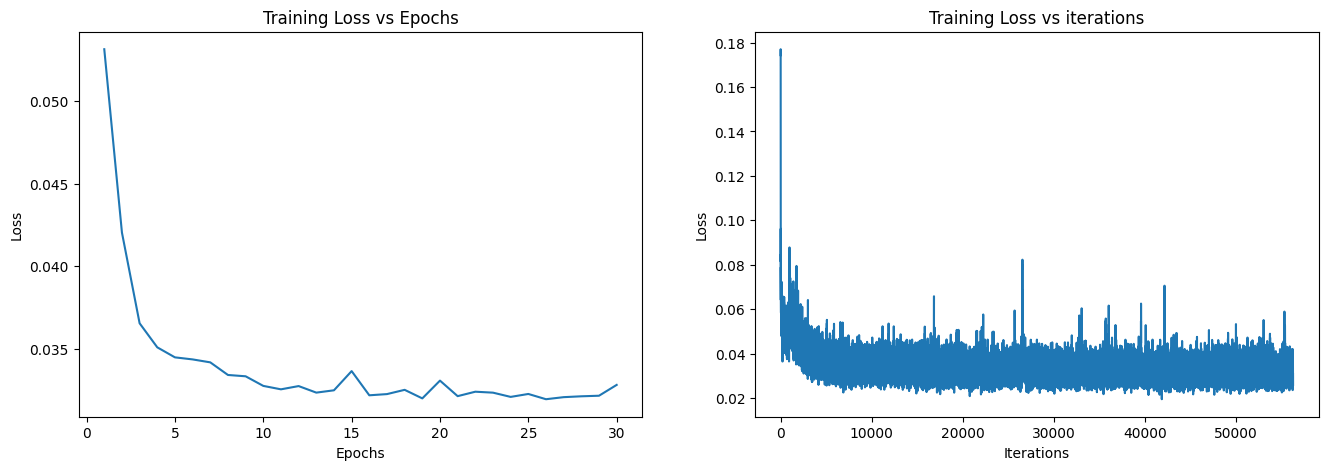

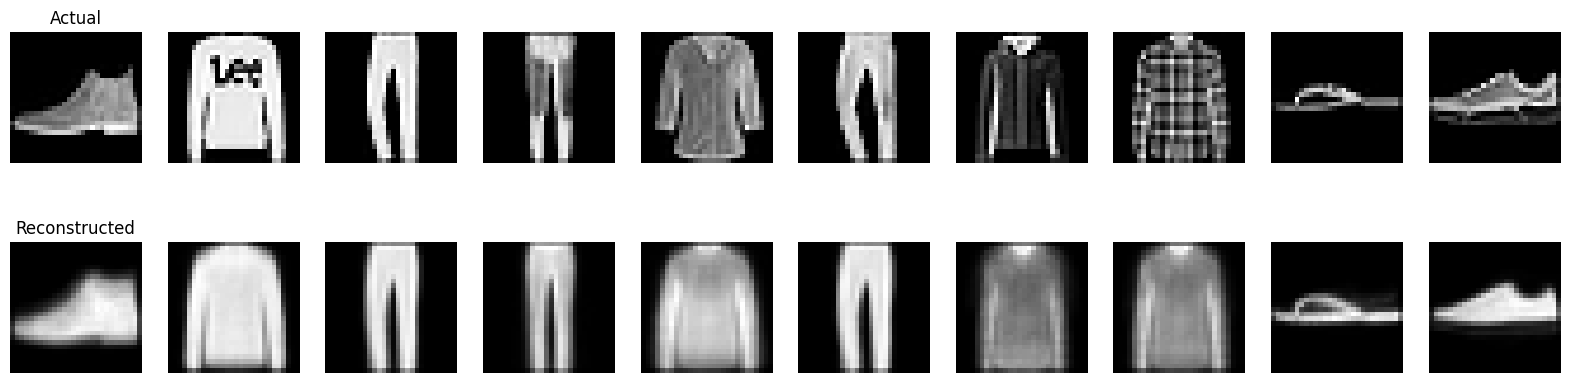

In [1]:
import torch
from torch import nn,optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.cuda.manual_seed(42)

class Autoencoder_fashionMNIST(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder=nn.Sequential(
        nn.Linear(28*28,512),
        nn.ReLU(),
        nn.Linear(512,256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32), #Latent Dimension
        nn.ReLU()
    )
    self.decoder=nn.Sequential(
        nn.Linear(32,64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128,256),
        nn.ReLU(),
        nn.Linear(256,512),
        nn.ReLU(),
        nn.Linear(512,28*28),
        nn.Sigmoid()
    )

  def forward(self,x):
    x_flattened = x.view(-1, 28*28)
    encoded = self.encoder(x_flattened)
    decoded = self.decoder(encoded)
    decoded = decoded.view(-1, 1, 28, 28)
    return decoded

train_dataset=datasets.FashionMNIST('data',train=True,download=True,transform=transforms.ToTensor())
test_dataset=datasets.FashionMNIST('data',train=False,download=True,transform=transforms.ToTensor())
BATCH_SIZE=32
train_dataloader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_dataloader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)
device = 'cuda' if torch.cuda.is_available() else 'cpu'#device agnostic code
model=Autoencoder_fashionMNIST()
model.to(device)
print(model)
loss_fn=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01) #this loss function works the best
epochs=30
model.train()
loss_history=[]
EPOCH_LOSS=[]
print("Training of the model starts...")
for epoch in range(epochs):
  loss_epoch=0
  for X,y in train_dataloader:
    X = X.to(device)
    y_pred=model(X)
    optimizer.zero_grad()
    loss=loss_fn(y_pred,X)
    loss.backward()
    optimizer.step()
    loss_epoch+=loss.item()
    loss_history.append(loss.item())
  epoch_loss=loss_epoch/len(train_dataloader)
  EPOCH_LOSS.append(epoch_loss)
  print(f"Epoch {epoch+1}| Train Loss {round(epoch_loss,6)}")

print("The Autoencoder Model has been Trained succesfully")

model.eval()
predicted=[]
Actual=[]
with torch.inference_mode():
  for X,y in test_dataloader:
    X = X.to(device) # Move input data to device
    y_pred=model(X)
    predicted.append(y_pred.cpu().numpy())
    Actual.append(X.cpu().numpy())
Figs,Axes=plt.subplots(ncols=2,nrows=1,figsize=(16,5))
Axes[0].plot(range(1,epochs+1),EPOCH_LOSS) # x-axis range for epochs
Axes[0].set_xlabel("Epochs")
Axes[0].set_ylabel("Loss")
Axes[0].set_title("Training Loss vs Epochs")
Axes[1].plot(range(1,len(loss_history)+1),loss_history) # plot arguments
Axes[1].set_xlabel("Iterations")
Axes[1].set_ylabel("Loss")
Axes[1].set_title("Training Loss vs iterations")
plt.show()
figs,axes=plt.subplots(nrows=2,ncols=10,figsize=(20,5))
for i in range(10):
  axes[0,i].imshow(Actual[0][i].reshape(28,28),cmap='gray') # Access first batch, i-th image
  axes[0,i].axis('off')
  axes[1,i].imshow(predicted[0][i].reshape(28,28),cmap='gray') # Access first batch, i-th image
  axes[1,i].axis('off')
  if i == 0:
    axes[0,i].set_title("Actual")
    axes[1,i].set_title("Reconstructed")
plt.show()